In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('/kaggle/input/datasets/tanadolsrisintron/titanicdataset-traincsv/train.csv')

In [3]:
# QUESTION 1 : HOW BIG IS THIS DATA?
df.shape
r,c = df.shape
# total no. of cells
r*c

10692

In [4]:
# QUESTION 2 :HOW DOES THE DATA LOOKS LIKE?
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
807,808,0,3,"Pettersson, Miss. Ellen Natalia",female,18.0,0,0,347087,7.7750,NaN,S
270,271,0,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S
292,293,0,2,"Levy, Mr. Rene Jacques",male,36.0,0,0,SC/Paris 2163,12.8750,D,C
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
308,309,0,2,"Abelson, Mr. Samuel",male,30.0,1,0,P/PP 3381,24.0000,NaN,C
540,541,1,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.0000,B22,S
843,844,0,3,"Lemberopolous, Mr. Peter L",male,34.5,0,0,2683,6.4375,NaN,C
135,136,0,2,"Richard, Mr. Emile",male,23.0,0,0,SC/PARIS 2133,15.0458,NaN,C
789,790,0,1,"Guggenheim, Mr. Benjamin",male,46.0,0,0,PC 17593,79.2000,B82 B84,C
154,155,0,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,NaN,S


In [7]:
#QUESTION 3 : WHAT IS THE DATA TYPES OF THE COLUMNS?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.dtypes.value_counts()

int64      5
object     5
float64    2
Name: count, dtype: int64

In [9]:
print(f'Total Memory : {df.memory_usage(deep = True).sum()/1024 :.2f}')

Total Memory : 285.61


In [10]:
# QUESTION 4 : ARE THERE ANY MISSING VALUES?
(df.isnull().sum()/len(df) *100).sort_values(ascending = False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [11]:
# QUESTION 5 : HOW DOES THE DATA LOOK MATHEMATICALLY?
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
round(df['Survived'].mean(),2)

np.float64(0.38)

In [13]:
# QUESTION 6 : ARE THERE DUPLICATE VALUES ?
df.duplicated().sum()

np.int64(0)

In [14]:
duplicated_ids = df['PassengerId'].duplicated().sum()
duplicated_ids

np.int64(0)

In [15]:
# QUESTION 7 : HOW IS THE CORRELATION BETWEEN COLUMNS?
print(df.corr(numeric_only = True))

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [16]:


numeric_df = df.select_dtypes(include='number')

print(numeric_df.corr())

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [17]:
df.corr(numeric_only = True)['Survived'].sort_values(ascending =  False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [18]:
# EXPLORATORY DATA ANALYSIS

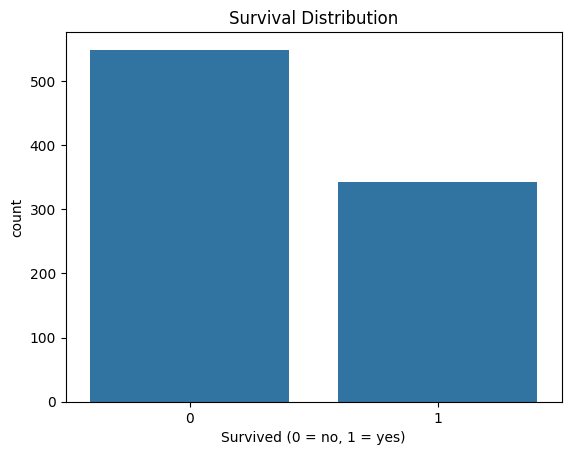

In [19]:
# UNIVARIATE EDA
# 1. SURVIVED (TARGET VARIABLE)
df['Survived'].value_counts()
sns.countplot(x='Survived', data = df)
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = no, 1 = yes)')
plt.ylabel('count')
plt.show()

In [20]:
survival_pct = df['Survived'].value_counts(normalize = True)*100
print(survival_pct)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


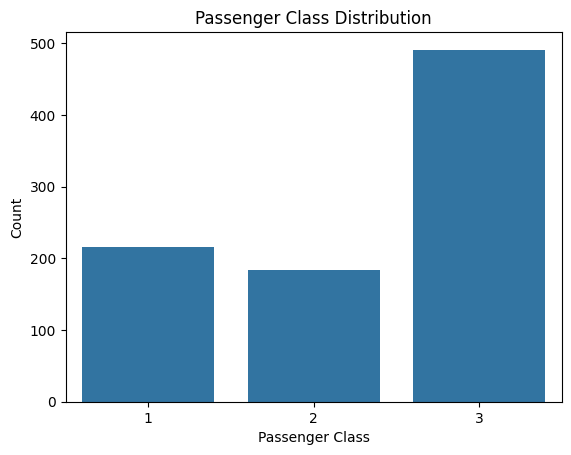

In [21]:
# 2. PCLASS
sns.countplot(x = 'Pclass', data = df)
plt.title ('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel ('Count')
plt.show()

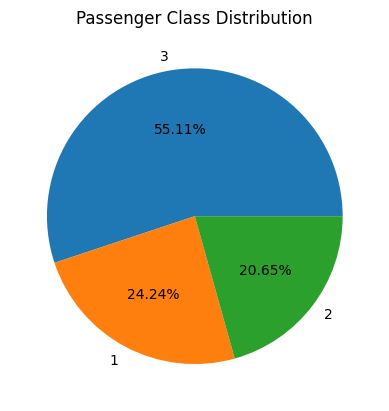

In [22]:
df['Pclass'].value_counts().plot(kind ='pie', autopct = '%.2f%%')
plt.title('Passenger Class Distribution')
plt.ylabel('')
plt.show()

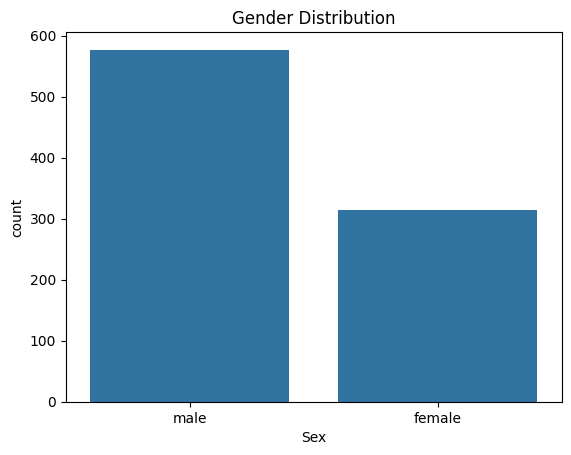

In [23]:
# 3. SEX( GENDER )
sns.countplot(x = 'Sex', data = df)
plt.title('Gender Distribution')
plt.show()


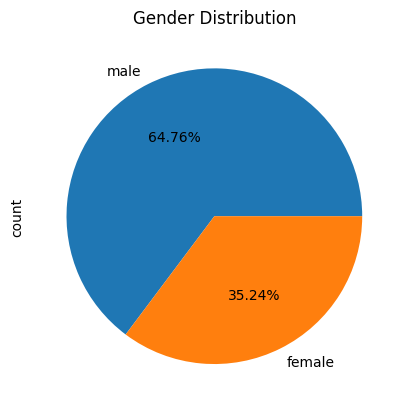

In [24]:
df['Sex'].value_counts().plot(kind = 'pie', autopct = '%.2f%%')
plt.title('Gender Distribution')
plt.show()

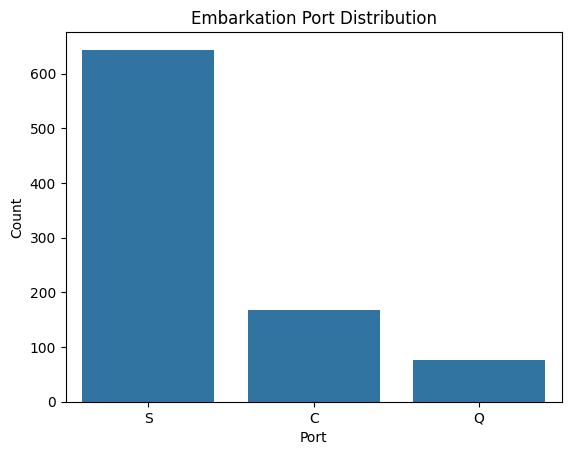

In [25]:
# 4. EMBARKED (PORT OF EMBARKATION)
sns.countplot(x = 'Embarked', data = df)
plt.title('Embarkation Port Distribution')
plt.xlabel('Port')
plt.ylabel('Count')
plt.show()

In [26]:
# 5. AGE (NUMERICAL VARIABLE)
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

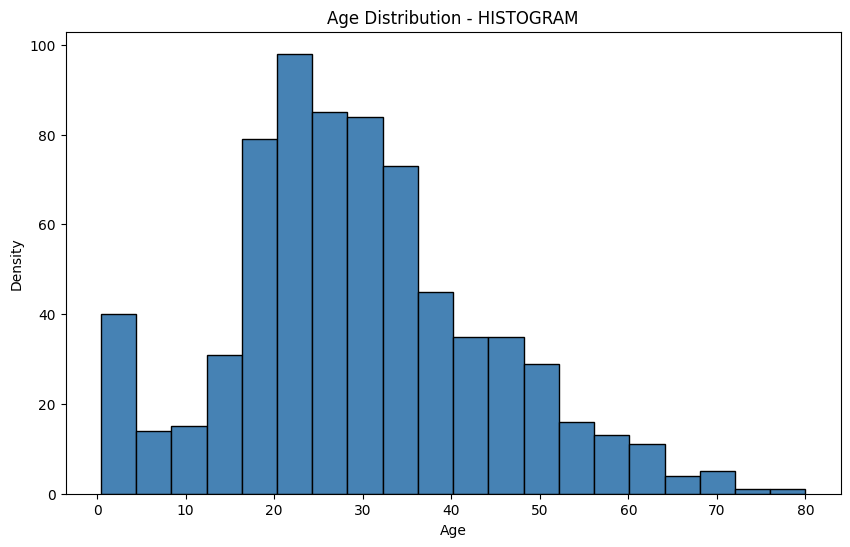

In [27]:
plt.figure(figsize = (10,6))
plt.hist(df['Age'].dropna(), bins = 20, color = 'steelblue', edgecolor = 'black')
plt.title('Age Distribution - HISTOGRAM')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

<Figure size 1000x600 with 0 Axes>

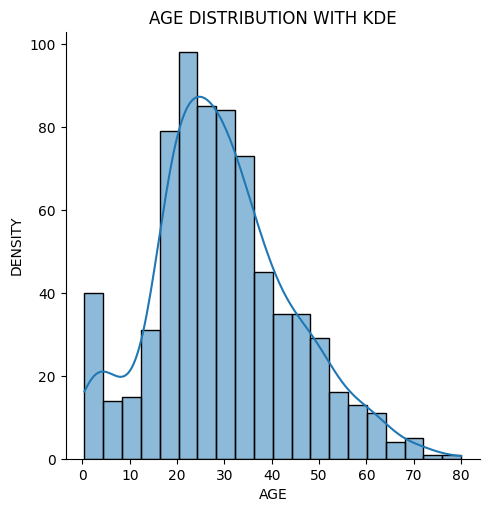

In [28]:
plt.figure(figsize = (10,6))
sns.displot(df['Age'].dropna(), kde = True, bins = 20)
plt.title('AGE DISTRIBUTION WITH KDE')
plt.xlabel('AGE')
plt.ylabel('DENSITY')
plt.show()

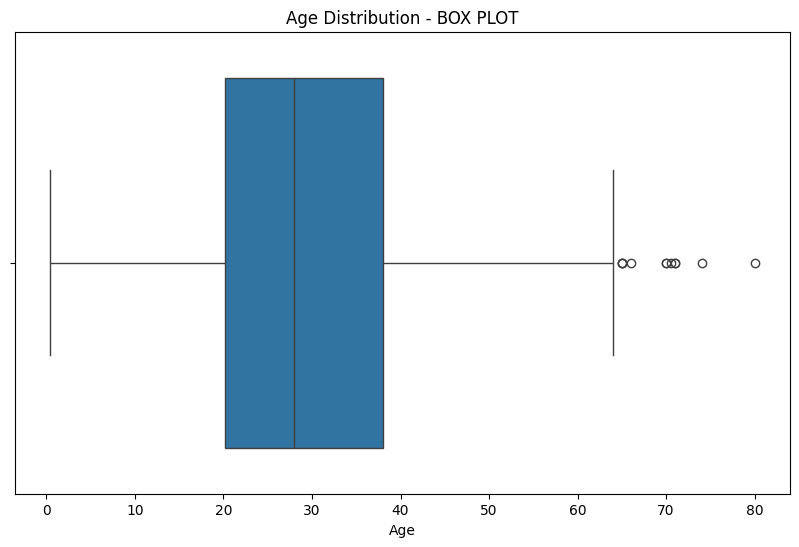

In [29]:
plt.figure(figsize = (10,6))
sns.boxplot(x=df['Age'])
plt.title('Age Distribution - BOX PLOT')
plt.xlabel('Age')
plt.show()

In [30]:
print(f'Skewness : {df['Age'].skew():.4f}')

Skewness : 0.3891


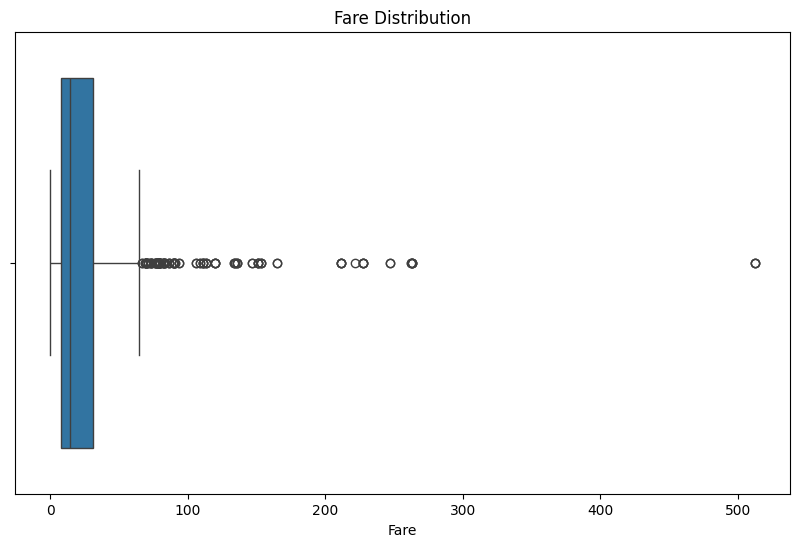

In [31]:
# 6. FARE (TICKET PRICE)
plt.figure(figsize = (10,6))
sns.boxplot(x = df['Fare'])
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.show()

In [32]:
print(df['Fare'].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [33]:
# MISSING DATA ANALYSIS
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing count' : missing_data,
    'percentage': missing_percentage
})
print(missing_summary[missing_summary['Missing count']>0].sort_values('Missing count'))

          Missing count  percentage
Embarked              2    0.224467
Age                 177   19.865320
Cabin               687   77.104377
